# Product Review Sentiment and Helpfulness Classification

Online product reviews provide valuable insights into customer opinions and purchasing behaviour. In addition to expressing sentiment, reviews vary in their usefulness to other consumers, making them an important source of information for both customers and businesses.

This project investigates two related text classification problems using product review data collected from an online retail platform:

* **Sentiment Classification:** Predicting whether a review expresses positive or negative sentiment.
* **Helpfulness Classification:** Predicting whether a review is likely to be considered helpful or unhelpful by other users.

The dataset consists of review text, star ratings, and review helpfulness information. To support the analysis, data from multiple sources were merged into a single analytical dataset before applying preprocessing, exploratory analysis, and machine learning techniques.

Several classification models were developed and evaluated to compare their effectiveness across both tasks. The results provide insight into the relative difficulty of sentiment and helpfulness prediction, while highlighting the strengths and limitations of different text classification approaches.
***

### Dataset Construction and Preprocessing

**Data Sources**

The analysis is based on two complementary datasets containing product review information:

* **Review Text Data** (`review-text.json`): Contains the textual content of customer reviews.
* **Review Metadata** (`review-scores.json`): Contains associated review scores, including star ratings and helpfulness information.

These datasets were merged using their common review identifiers to create a unified analytical dataset suitable for downstream analysis and machine learning tasks.

In [38]:
#Importing necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [39]:
reviews_text = pd.read_json("review-text.json")
reviews_scores = pd.read_json("review-scores.json")

reviews_text.head()

,review_id,product_id,user_id,review_title,review_body,review_date
0,R274002,B001O1Q0NA,AY6QZ7AY3AK8Z,Fluoridated salt,I thought this salt was fluoride free unfortun...,2021/01/01
1,R302264,B000MOEUMS,A33DXT3AD5DHCB,NOT as Advertised,This product is NOT drinking chocolate.<br /><...,01-01-2021
2,R84546,B002ZOIKMY,A14396UCW3Z0KI,"Best bags for iced tea, excellent deal","First, Luzianne makes the best classic brewed ...",2021-01-01
3,R117515,B0016B7Z32,A1ODU9IV6O87IB,"Don't pay for ""expedited"" delivery","I paid over $13.00 for ""expedited"" delivery an...",01-01-2021
4,R131840,B001XUO8AY,A3LOCNXB7Z1WCH,I love Fever-Tree!,After doing an Internet search for tonic water...,01 Jan 2021


Before merging the datasets, it is important to understand their structure, including the available columns and data types.

In [40]:
reviews_text.info()
reviews_scores.info()

<class 'pandas.DataFrame'>
RangeIndex: 15375 entries, 0 to 15374
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   review_id     15375 non-null  str  
 1   product_id    15375 non-null  str  
 2   user_id       15375 non-null  str  
 3   review_title  15330 non-null  str  
 4   review_body   15330 non-null  str  
 5   review_date   15375 non-null  str  
dtypes: str(6)
memory usage: 720.8 KB
<class 'pandas.DataFrame'>
RangeIndex: 15375 entries, 0 to 15374
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   review_id      15375 non-null  str  
 1   rating         15375 non-null  str  
 2   helpful_votes  15375 non-null  int64
 3   total_votes    15375 non-null  int64
dtypes: int64(2), str(2)
memory usage: 480.6 KB


The two datasets are merged using the 'review_id' field, which uniquely identifies each review. This step creates a single dataset that combines review text with rating and helpfulness information.

In [41]:
df = pd.merge(reviews_text, reviews_scores, on="review_id")

df.head()

,review_id,product_id,user_id,review_title,review_body,review_date,rating,helpful_votes,total_votes
0,R274002,B001O1Q0NA,AY6QZ7AY3AK8Z,Fluoridated salt,I thought this salt was fluoride free unfortun...,2021/01/01,*,17,24
1,R302264,B000MOEUMS,A33DXT3AD5DHCB,NOT as Advertised,This product is NOT drinking chocolate.<br /><...,01-01-2021,***,6,12
2,R84546,B002ZOIKMY,A14396UCW3Z0KI,"Best bags for iced tea, excellent deal","First, Luzianne makes the best classic brewed ...",2021-01-01,*****,18,18
3,R117515,B0016B7Z32,A1ODU9IV6O87IB,"Don't pay for ""expedited"" delivery","I paid over $13.00 for ""expedited"" delivery an...",01-01-2021,**,4,22
4,R131840,B001XUO8AY,A3LOCNXB7Z1WCH,I love Fever-Tree!,After doing an Internet search for tonic water...,01 Jan 2021,*****,16,16


The merged dataset is saved in CSV format. This allows the dataset to be reused without repeating the data integration process.

In [42]:
df.to_csv("merged_reviews.csv", index=False)

### Data Preprocessing and Preparation  

Before analysis, several preprocessing steps were performed to improve data quality and ensure consistency across the merged dataset. These steps included:

* Removing missing or invalid values.
* Ensuring correct data types.
* Creating additional useful features where necessary.
* Loading and parsing the JSON data files.
* Merging review text with associated review metadata.
* Identifying and handling missing or incomplete records.
* Converting variables into appropriate data types.
* Creating derived features required for subsequent classification tasks.

The resulting dataset serves as the Analytics Base Table (ABT) used throughout the remainder of this project.

In [43]:
# Check for missing values
df.isnull().sum()

review_id         0
product_id        0
user_id           0
review_title     45
review_body      45
review_date       0
rating            0
helpful_votes     0
total_votes       0
dtype: int64

In [44]:
# Removal of rows with missing key values
df = df.dropna(subset=["review_body", "rating"])

df.shape

(15330, 9)

The rating column contains values represented as star symbols (e.g., "*", "***"). A numeric version of the rating is created by counting the number of stars. This allows easier analysis and visualisation.

In [45]:
df["rating_length"] = df["rating"].apply(len)

Helpfulness Ratio - A new feature is created to represent the proportion of helpful votes for each review. This feature will later be used to define the helpfulness classification task.

In [46]:
df["helpfulness_ratio"] = df["helpful_votes"] / df["total_votes"]

df["helpfulness_ratio"] = df["helpfulness_ratio"].fillna(0)

### Dataset Characterisation

This section provides an overview of the dataset using summary statistics and visualisations. The goal is to better understand the distribution of key variables before applying machine learning techniques. Following preprocessing, the dataset was explored to understand its structure and key characteristics. Summary statistics and visualisations were used to examine:

* Review rating distributions.
* Helpfulness score distributions.
* Review length characteristics.
* Class balance for the target variables.
* General trends within the review data.

This exploratory analysis provides context for the classification tasks and helps identify patterns that may influence model performance.

In [47]:
#Dataset Overview
df.info()

<class 'pandas.DataFrame'>
Index: 15330 entries, 0 to 15374
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   review_id          15330 non-null  str    
 1   product_id         15330 non-null  str    
 2   user_id            15330 non-null  str    
 3   review_title       15330 non-null  str    
 4   review_body        15330 non-null  str    
 5   review_date        15330 non-null  str    
 6   rating             15330 non-null  str    
 7   helpful_votes      15330 non-null  int64  
 8   total_votes        15330 non-null  int64  
 9   rating_length      15330 non-null  int64  
 10  helpfulness_ratio  15330 non-null  float64
dtypes: float64(1), int64(3), str(7)
memory usage: 1.4 MB


### Exploratory Data Analysis

To better understand the dataset, descriptive statistics and visualisations were generated for the main review attributes. Examining feature distributions prior to modelling helps identify potential data quality issues, class imbalances, and characteristics that may affect classification performance.

In [48]:
#Summary Statistics
df.describe()

,helpful_votes,total_votes,rating_length,helpfulness_ratio
count,15330.000000,15330.000000,15330.000000,15330.000000
mean,21.936725,27.134573,3.415134,0.767173
std,36.343259,37.229639,1.746885,0.291009
min,0.000000,12.000000,1.000000,0.000000
25%,10.000000,14.000000,1.000000,0.666667
50%,14.000000,18.000000,4.000000,0.904762
75%,22.000000,26.000000,5.000000,0.987548
max,866.000000,923.000000,5.000000,1.000000


Distribution of Ratings - This chart shows how review ratings are distributed across the dataset. Understanding this distribution is important because it affects how sentiment labels will be generated in later tasks.

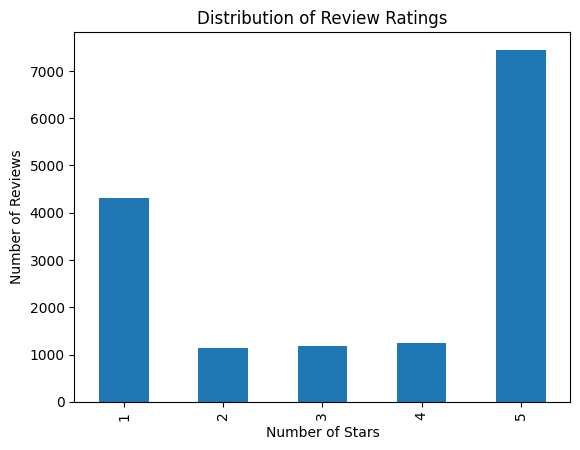

In [49]:
df["rating_length"].value_counts().sort_index().plot(kind="bar")

plt.title("Distribution of Review Ratings")
plt.xlabel("Number of Stars")
plt.ylabel("Number of Reviews")
plt.show()

This plot shows the distribution of helpful votes across reviews. It provides insight into how frequently reviews are considered useful by other users.

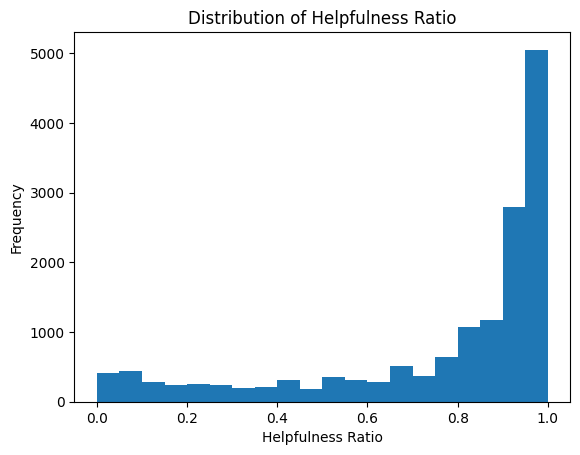

In [50]:
plt.hist(df["helpfulness_ratio"], bins=20)

plt.title("Distribution of Helpfulness Ratio")
plt.xlabel("Helpfulness Ratio")
plt.ylabel("Frequency")
plt.show()

The length of review text is analysed to understand how detailed the reviews are. This feature may influence both sentiment and helpfulness predictions.

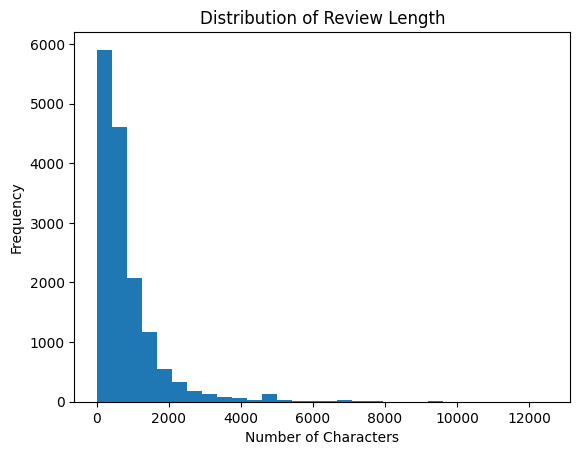

In [51]:
df["review_length"] = df["review_body"].apply(len)

plt.hist(df["review_length"], bins=30)

plt.title("Distribution of Review Length")
plt.xlabel("Number of Characters")
plt.ylabel("Frequency")
plt.show()

**Summary**

Successfully combined the two sources into one analytics dataset, which included review texts, their star rating, and the information about how helpful those reviews were. Conducted several operations on the data to enhance its quality and enrich it with new features like review lengths and helpfulness rates.

The exploratory analysis helped discover the essential features of the dataset, as well as understand rating distributions, helpfulness tendencies and variability in review lengths. These results helped develop a strong basis of knowledge about the data that could be used to improve classification efficiency.

This is how the Analytics Base Table (ABT) was formed, laying the ground for the classification models that will be described in the following parts of the report.
***

### Sentiment Classification

The objective of this task is to build machine learning models to classify review sentiment as either positive or negative.

This involves:

- Creating a binary sentiment label from the rating data
- Exploring the class distribution
- Preprocessing the text data into a numerical format
- Training two classification models
- Evaluating and comparing their performance

This task demonstrates how text data can be transformed and used in supervised learning models.

Creating Sentiment Labels - The dataset contains ratings represented as star symbols (e.g., "*", "***", "*****"). To perform sentiment classification, these ratings are converted into binary labels:

- Reviews with 4 or 5 stars → positive
- Reviews with 1 to 3 stars → negative

This transformation simplifies the classification task into a binary problem.

In [52]:
def get_sentiment(rating):
    if len(rating) >= 4:
        return "positive"
    else:
        return "negative"

df["sentiment"] = df["rating"].apply(get_sentiment)

df[["rating", "sentiment"]].head()

,rating,sentiment
0,*,negative
1,***,negative
2,*****,positive
3,**,negative
4,*****,positive


It is important to examine the distribution of sentiment classes before training models. Imbalanced datasets can affect model performance and lead to biased predictions.

In [53]:
df["sentiment"].value_counts()

sentiment
positive    8688
negative    6642
Name: count, dtype: int64

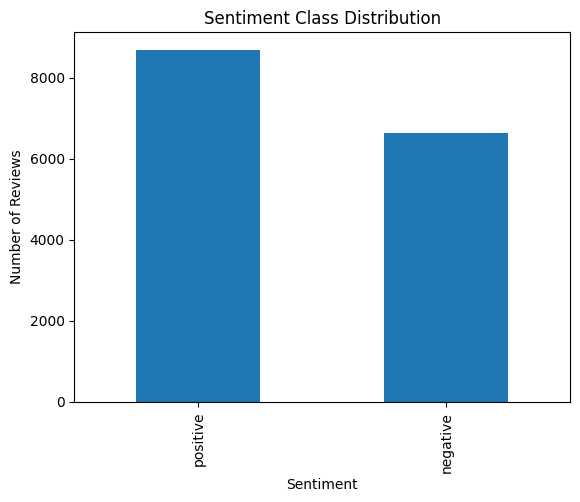

In [54]:
df["sentiment"].value_counts().plot(kind="bar")

plt.title("Sentiment Class Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.show()

Machine learning models cannot process raw text directly. Therefore, the review text must be transformed into a numerical representation.

In this task, the TF-IDF (Term Frequency–Inverse Document Frequency) method is used. TF-IDF converts text into a matrix of numerical features that represent the importance of words in each document.

In [55]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(stop_words="english", max_features=5000)

X = vectorizer.fit_transform(df["review_body"])
y = df["sentiment"]

The dataset is split into training and testing sets.

- Training data is used to train the models
- Testing data is used to evaluate model performance on unseen data

In [56]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

**Model 1: Logistic Regression**

Logistic Regression is a widely used classification algorithm for binary problems. It models the probability that a given input belongs to a particular class.

In [57]:
from sklearn.linear_model import LogisticRegression

model1 = LogisticRegression(max_iter=1000)
model1.fit(X_train, y_train)

pred1 = model1.predict(X_test)

**Model 2: Multinomial Naive Bayes**

Naive Bayes is particularly well-suited for text classification tasks. It assumes independence between features and is efficient for high-dimensional data such as text.

In [58]:
from sklearn.naive_bayes import MultinomialNB

model2 = MultinomialNB()
model2.fit(X_train, y_train)

pred2 = model2.predict(X_test)

The performance of both models is evaluated using standard classification metrics:

- Accuracy
- Precision
- Recall
- F1-score

In [59]:
from sklearn.metrics import accuracy_score, classification_report

In [60]:
print("Logistic Regression Accuracy:", accuracy_score(y_test, pred1))
print("\nClassification Report:\n")
print(classification_report(y_test, pred1))

Logistic Regression Accuracy: 0.8542074363992173

Classification Report:

              precision    recall  f1-score   support

    negative       0.87      0.80      0.83      1384
    positive       0.85      0.90      0.87      1682

    accuracy                           0.85      3066
   macro avg       0.86      0.85      0.85      3066
weighted avg       0.85      0.85      0.85      3066



In [61]:
print("Naive Bayes Accuracy:", accuracy_score(y_test, pred2))
print("\nClassification Report:\n")
print(classification_report(y_test, pred2))

Naive Bayes Accuracy: 0.8052837573385518

Classification Report:

              precision    recall  f1-score   support

    negative       0.85      0.69      0.76      1384
    positive       0.78      0.90      0.84      1682

    accuracy                           0.81      3066
   macro avg       0.81      0.80      0.80      3066
weighted avg       0.81      0.81      0.80      3066



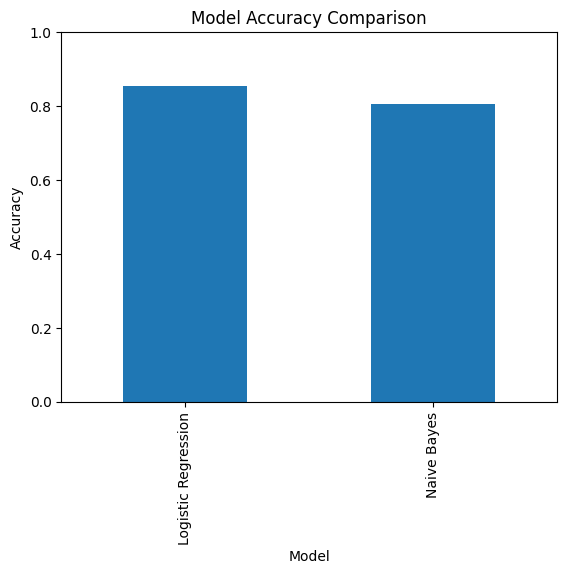

In [62]:
import pandas as pd

model_names = ["Logistic Regression", "Naive Bayes"]
accuracies = [accuracy_score(y_test, pred1), accuracy_score(y_test, pred2)]

results_df = pd.DataFrame({
    "Model": model_names,
    "Accuracy": accuracies
})

results_df.plot(x="Model", y="Accuracy", kind="bar", legend=False)

plt.title("Model Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.ylim(0,1)

plt.show()

In [ ]:
# Saving Task 2 variables
y_test_sentiment = y_test

**Model Comparison**

The performance of these two classifiers is gauged using the accuracy, precision, recall and the F1-score values.

In terms of accuracy, Logistic Regression gave a slightly higher value of 85.4%, in comparison to Naive Bayes with only 80.5%. This demonstrates that Logistic Regression has better predictive ability on this dataset.

A more detailed evaluation by class shows that:

- Logistic Regression has a higher recall value (0.80) for the negative class, compared to that of the Naive Bayes classifier (0.69), thus making the former better in predicting the negatives.
- As far as the positive class goes, there is not much difference in the recall rates; however, Logistic Regression manages to get a good balance of precision and recall rates.

This means that Logistic Regression outperforms Naive Bayes when evaluating its performance with respect to both classes, while Naive Bayes performs better at predicting the positive class.

**Interpretation of Results**

As shown in the above results, the two models can be considered to be able to classify review sentiments effectively using the text data.

The logistic regression model outperforms the other model by having higher accuracy rate and balanced precision and recall rates for both categories of data. This is an indication that this model can capture the relationship between the review words and their corresponding sentiments more than Naïve Bayes.

The Naïve Bayes was not as accurate as the first one but it is still relatively good when it comes to identifying positive review sentiments. On the contrary, the low recall rate for the negative category shows that there is difficulty in differentiating negative review sentiments from positive ones.

From the results obtained, it can be seen that text classification using TF-IDF as features worked perfectly since the two algorithms achieved good results.

Moreover, the results show that the sentiment classification from the text is relatively simple to make, considering the high accuracy rate recorded using the simple features. Therefore, logistic regression is the model preferred for the given task.

**Summary**

Here, we generated a binary variable based on the rating value in the reviews, classifying the reviews as positive or negative. The reviews were converted into numerical values using TF-IDF, which helped in applying the machine learning models on the dataset. We applied two different classification algorithms, i.e., Logistic Regression and Multinomial Naive Bayes, on our data.

From the results, we observed that the Logistic Regression algorithm performed better than the Naive Bayes algorithm. This concludes the first part of our task, where we used a simple binary classification problem to predict sentiments in the reviews. Now we have our dataset ready for the next task, i.e., predicting the helpfulness of the reviews using classification algorithms.
***

### Helpfulness Classification

The objective of this task is to classify reviews as either helpful or unhelpful based on their associated helpfulness information.

This task involves:

- Creating a binary helpfulness label using helpfulness votes
- Exploring the class distribution
- Training two classification models
- Evaluating and comparing their performance
- Comparing results with the sentiment classification task

This task demonstrates how textual data can be used to predict the perceived usefulness of reviews.

The dataset includes two fields related to helpfulness:

- helpful_votes: number of users who found the review helpful  
- total_votes: total number of votes  

A helpfulness ratio is calculated as : helpfulness_ratio = helpful_votes / total_votes

A binary label is then created:

- Reviews with ratio ≥ 0.5 → helpful
- Reviews with ratio < 0.5 → unhelpful

This converts the problem into a binary classification task.

In [64]:
df["helpfulness_ratio"] = df["helpful_votes"] / df["total_votes"]

df["helpfulness_ratio"] = df["helpfulness_ratio"].fillna(0)

df["helpful"] = df["helpfulness_ratio"].apply(
    lambda x: "helpful" if x >= 0.5 else "unhelpful"
)

df[["helpful_votes", "total_votes", "helpfulness_ratio", "helpful"]].head()

,helpful_votes,total_votes,helpfulness_ratio,helpful
0,17,24,0.708333,helpful
1,6,12,0.500000,helpful
2,18,18,1.000000,helpful
3,4,22,0.181818,unhelpful
4,16,16,1.000000,helpful


The distribution of helpful and unhelpful reviews is examined to understand class balance. Class imbalance can significantly affect classification performance.

In [65]:
df["helpful"].value_counts()

helpful
helpful      12569
unhelpful     2761
Name: count, dtype: int64

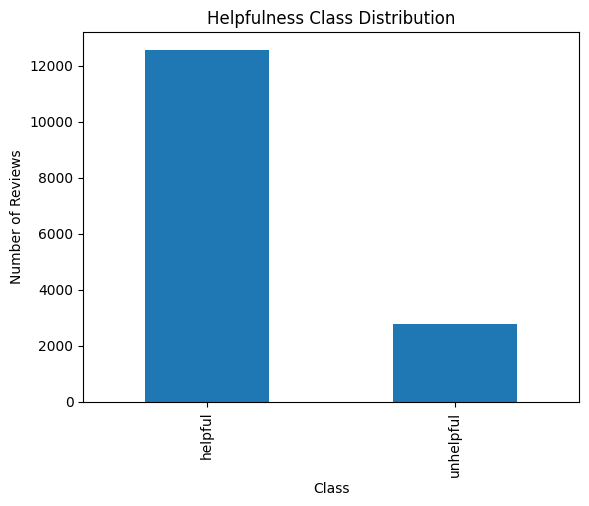

In [66]:
df["helpful"].value_counts().plot(kind="bar")

plt.title("Helpfulness Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Reviews")
plt.show()

The same TF-IDF representation used in Sentiment Classification is applied here to transform the review text into numerical features. This ensures consistency between the sentiment and helpfulness classification tasks.

In [67]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(stop_words="english", max_features=5000)

X = vectorizer.fit_transform(df["review_body"])
y = df["helpful"]

The dataset is split into training and testing sets to evaluate model performance on unseen data.

In [68]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

**Model 1: Logistic Regression**

Logistic Regression is used as a baseline model for this classification task.

In [69]:
from sklearn.linear_model import LogisticRegression

model1_h = LogisticRegression(max_iter=1000)
model1_h.fit(X_train, y_train)

pred1_h = model1_h.predict(X_test)

**Model 2: Multinomial Naive Bayes**

Naive Bayes is applied again due to its effectiveness in text classification problems.

In [70]:
from sklearn.naive_bayes import MultinomialNB

model2_h = MultinomialNB()
model2_h.fit(X_train, y_train)

pred2_h = model2_h.predict(X_test)

The performance of the models is evaluated using accuracy, precision, recall, and F1-score.

In [71]:
from sklearn.metrics import accuracy_score, classification_report

In [72]:
print("Logistic Regression Accuracy:", accuracy_score(y_test, pred1_h))
print("\nClassification Report:\n")
print(classification_report(y_test, pred1_h))

Logistic Regression Accuracy: 0.8519243313763861

Classification Report:

              precision    recall  f1-score   support

     helpful       0.86      0.98      0.92      2519
   unhelpful       0.77      0.24      0.37       547

    accuracy                           0.85      3066
   macro avg       0.81      0.61      0.64      3066
weighted avg       0.84      0.85      0.82      3066



In [73]:
print("Naive Bayes Accuracy:", accuracy_score(y_test, pred2_h))
print("\nClassification Report:\n")
print(classification_report(y_test, pred2_h))

Naive Bayes Accuracy: 0.8339856490541422

Classification Report:

              precision    recall  f1-score   support

     helpful       0.84      0.99      0.91      2519
   unhelpful       0.72      0.12      0.20       547

    accuracy                           0.83      3066
   macro avg       0.78      0.55      0.55      3066
weighted avg       0.82      0.83      0.78      3066



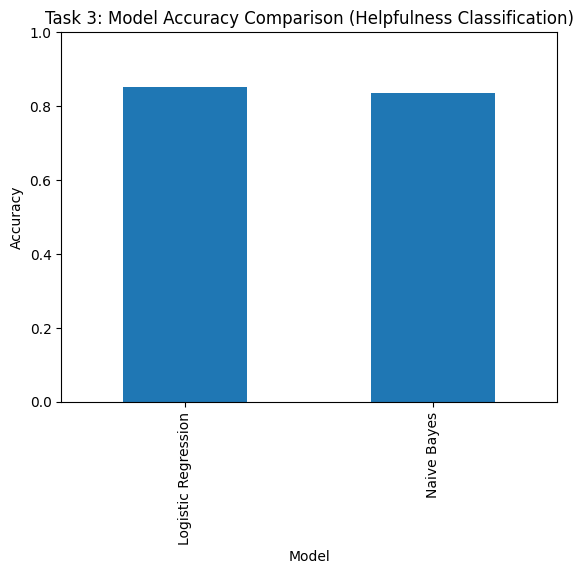

In [74]:
import pandas as pd
from sklearn.metrics import accuracy_score

# Task 3 accuracies
model_names = ["Logistic Regression", "Naive Bayes"]
accuracies_task3 = [
    accuracy_score(y_test, pred1_h),
    accuracy_score(y_test, pred2_h)
]

results_task3 = pd.DataFrame({
    "Model": model_names,
    "Accuracy": accuracies_task3
})

results_task3.plot(x="Model", y="Accuracy", kind="bar", legend=False)

plt.title("Task 3: Model Accuracy Comparison (Helpfulness Classification)")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.ylim(0,1)

plt.show()

**Model Comparison**

Both Logistic Regression and Multinomial Naive Bayes models were tested on their performance in solving the classification problem of helpfulness.

Logistic Regression showed slight superiority over Naive Bayes in terms of accuracy, producing the latter at the level of about 85.1%, whereas the former scored 83.4%. The difference is small enough but sufficient to conclude that Logistic Regression shows better predictive performance.

Nevertheless, the class-based evaluation of these models gives interesting results:

- The performance in class "helpful" is rather satisfactory for both models, having very high recall (0.98–0.99).
- The performance in class "unhelpful" is rather unsatisfactory for both models, especially recall:
  - Logistic Regression recall: 0.24
  - Naive Bayes recall: 0.12

Thus, both models cannot recognize the minority class, tending to classify this class instances as those of majority class. Generally speaking, Logistic Regression slightly outperforms Naive Bayes. Both models are heavily biased towards predicting the majority class.

**Interpretation of Results**

The above results reveal that the problem of helpfulness classification is a lot more complex than that of sentiment classification.

A notable reason behind the low performances in these experiments is the fact of "class imbalance". The data set consists of a much greater number of helpful reviews compared to unhelpful reviews, causing an increased tendency towards the former category by the classifiers. This is evident from the extremely high recall of helpful class, whereas the unhelpful class recall is extremely low. Although the classifiers yield good accuracy rates, this should not be taken into account since they cannot distinguish between helpfulness and unhelpfulness efficiently.

The other cause of the increased difficulty of the problem is the nature of helpfulness itself, which is never explicitly mentioned in the text. As a consequence, such attributes as clarity, specificity and usefulness cannot be used when calculating TF-IDF values. 

In general, more advanced methods might be required in order to achieve better results.

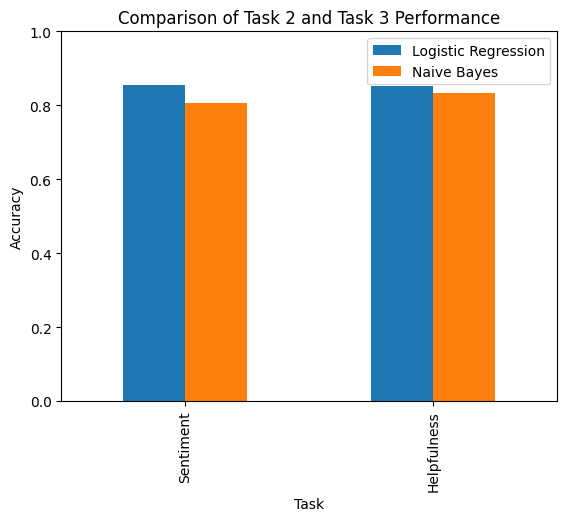

In [75]:
# Task 2 accuracies (use your earlier results)
acc_task2_lr = accuracy_score(y_test_sentiment, pred1)
acc_task2_nb = accuracy_score(y_test_sentiment, pred2)

# Task 3 accuracies
acc_task3_lr = accuracy_score(y_test, pred1_h)
acc_task3_nb = accuracy_score(y_test, pred2_h)

comparison_df = pd.DataFrame({
    "Logistic Regression": [acc_task2_lr, acc_task3_lr],
    "Naive Bayes": [acc_task2_nb, acc_task3_nb]
}, index=["Sentiment", "Helpfulness"])

comparison_df.plot(kind="bar")

plt.title("Comparison of Task 2 and Task 3 Performance")
plt.xlabel("Task")
plt.ylabel("Accuracy")
plt.ylim(0,1)

plt.show()

**Comparison with Sentiment Classification**

A comparison of the outcomes of sentiment classification and helpfulness classification reveals some notable distinctions between the two. The former yielded better accuracy rates – up to 85.4% for Logistic Regression – as well as precision and recall scores that were relatively close.

By contrast, while the models produced a high accuracy rate in helpfulness classification (approximately 85%), there was a significant disparity in the performance metrics of the respective classes. Specifically, they scored high in identifying the helpful class but low in detecting the unhelpful one.

This difference may be accounted for by the following facts:

- Sentiment classification is a simpler task since sentiment can be determined based on the positive or negative language used in the text.
- Helpfulness classification is a complex and rather subjective process that involves a variety of elements beyond textual content.

Additionally, the problem of class imbalance was much more pronounced in the latter task, which adversely affected its performance in recognizing the minority class.

Thus, sentiment classification appears to be a relatively simple and predictable process, whereas helpfulness classification is a more complicated endeavor requiring more advanced methods.

**Summary**

For this problem, a binary label for the helpfulness of reviews was generated based on the percentage of helpful votes received by each review. Logistic Regression and Multinomial Naive Bayes classifiers were then used to predict the helpfulness of a review given the textual content.

The analysis indicated that both the Logistic Regression classifier and the Multinomial Naive Bayes classifier produced reasonably accurate predictions, although the Logistic Regression classifier performed marginally better than the Multinomial Naive Bayes classifier.

However, the inability of the models to accurately predict the helpfulness of negative reviews stems from the imbalance between classes and the subjectivity associated with determining the helpfulness of reviews.
***

**Conclusion**

This project demonstrated the application of data analysis and machine learning techniques to a real-world dataset of product reviews.

Firstly, the data was successfully imported from two different JSON files into one common dataset. Then preprocessing was carried out on the obtained data, which included handling of missing data and creation of additional features like the length of the review text and helpfulness ratio. After that, a statistical description of the dataset was made, where insights into rating distribution, review length, and helpfulness were found.

Secondly, a classification problem was considered, namely the problem of classifying reviews by sentiments. Sentiments were encoded as binary features, while the reviews' texts were converted to numbers through TF-IDF vectorization. For solving the problem, two machine learning models were used: logistic regression and multinomial naive bayes. It can be seen that for sentiment classification, logistic regression performed better in terms of accuracy, with more equal F1 scores across all sentiments. Generally speaking, classification on this task turned out to be quite simple, since sentiments are easy to distinguish in textual data.

Lastly we determined whether a review is useful or not. In order to generate a helpfulness label, we took into account the proportion of 'helpful' votes versus the total number of votes. The models we used were again Logistic Regression and Naive Bayes classifiers. Both classifiers yielded relatively high accuracies, but, like before, their effectiveness was considerably influenced by class imbalance. Namely, they had problems recognizing unhelpful reviews which led to poor recall scores for the class that was underrepresented.

Comparing tasks showed several key distinctions between them. While both tasks yielded comparable scores, it appeared that the former task was relatively easier to accomplish than the latter. This difference stems from the fact that while there exists a direct connection between text and sentiment, such a link cannot be established in the case of helpfulness classification.

On the whole, this assignment showed how efficient text features might be used in order to perform sentiment analysis, although they are not sufficient for predicting more complex parameters like helpfulness. The role of data pre-processing and representation, as well as the proper model choice in machine learning, was evident too.

As for future work, the performance of the algorithms in use could be enhanced by introducing class balancing, advanced models like ensembles or deep learning approaches, and other types of features except those based on text.

To conclude, the assignment helped to understand how important both technological implementation and critical thinking are when applying machine learning to real-life problems.